# Exploracion de datos

Notebook para revisar los datasets originales y sus estadisticas basicas antes o despues del ETL.

In [2]:
# 1. Importación de librerías esenciales
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Configuración visual por defecto para los gráficos de Seaborn
sns.set_theme(style="whitegrid")

# 3. Definir la ruta (se usa "../" para salir de notebooks/ y entrar a data/raw/)
ruta_archivo = '../data/raw/database.csv'

# 4. Cargar los datos en el DataFrame
df = pd.read_csv(ruta_archivo)

# 5. Visualizar las primeras 5 filas
df.head()

C:\Users\Emiliano\AppData\Local\Temp\ipykernel_14624\115053799.py:13: DtypeWarning: Columns (9: Aircraft Model, 12: Engine Model, 15: Engine1 Position, 17: Engine3 Position) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta_archivo)


,Record ID,Incident Year,Incident Month,Incident Day,Operator ID,Operator,Aircraft,Aircraft Type,Aircraft Make,Aircraft Model,...,Fuselage Strike,Fuselage Damage,Landing Gear Strike,Landing Gear Damage,Tail Strike,Tail Damage,Lights Strike,Lights Damage,Other Strike,Other Damage
0,127128,1990,1,1,DAL,DELTA AIR LINES,B-757-200,A,148,26,...,0,0,0,0,1,1,0,0,0,0
1,129779,1990,1,1,HAL,HAWAIIAN AIR,DC-9,A,583,90,...,0,0,0,0,0,0,0,0,1,0
2,129780,1990,1,2,UNK,UNKNOWN,UNKNOWN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
3,2258,1990,1,3,MIL,MILITARY,A-10A,A,345,NaN,...,0,0,0,0,0,0,0,0,0,0
4,2257,1990,1,3,MIL,MILITARY,F-16,A,561,NaN,...,0,0,0,0,0,0,0,0,0,0


In [17]:
columnas_clave = ['Record ID', 'Incident Year', 'Incident Month', 'Incident Day', 
                  'Operator ID', 'Operator', 'Aircraft']
df_analisis = df[columnas_clave]
df_analisis.head(3) # Para verificar que se recortó bien

,Record ID,Incident Year,Incident Month,Incident Day,Operator ID,Operator,Aircraft
0,127128,1990,1,1,DAL,DELTA AIR LINES,B-757-200
1,129779,1990,1,1,HAL,HAWAIIAN AIR,DC-9
2,129780,1990,1,2,UNK,UNKNOWN,UNKNOWN


In [18]:
print("IDs duplicados:", df_analisis['Record ID'].duplicated().sum())
print("\nValores nulos en identificadores:")
print(df_analisis[['Record ID', 'Operator ID', 'Aircraft']].isnull().sum())

IDs duplicados: 0

Valores nulos en identificadores:
Record ID      0
Operator ID    0
Aircraft       0
dtype: int64


       Incident Year  Incident Month   Incident Day
count  174104.000000   174104.000000  174104.000000
mean     2006.036392        7.171840      15.712264
std         6.747708        2.790152       8.799405
min      1990.000000        1.000000       1.000000
25%      2001.000000        5.000000       8.000000
50%      2007.000000        8.000000      16.000000
75%      2012.000000        9.000000      23.000000
max      2015.000000       12.000000      31.000000


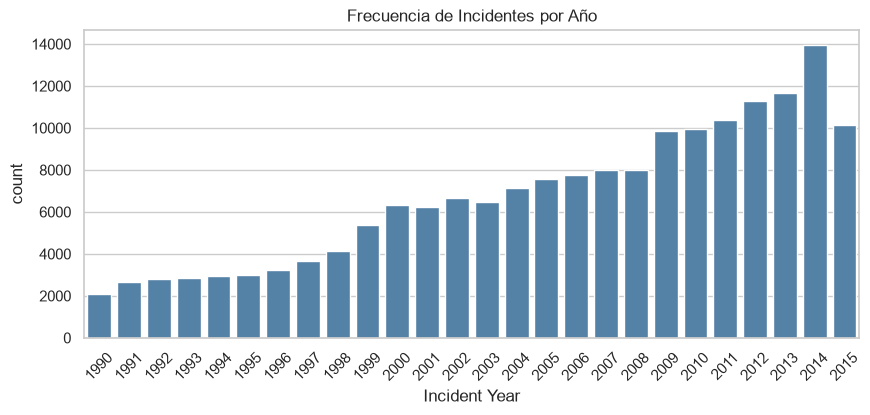

In [19]:
print(df_analisis[['Incident Year', 'Incident Month', 'Incident Day']].describe())

plt.figure(figsize=(10, 4))
sns.countplot(data=df_analisis, x='Incident Year', color='steelblue')
plt.xticks(rotation=45)
plt.title('Frecuencia de Incidentes por Año')
plt.show()

Top 10 Operadores:
 Operator
UNKNOWN               39540
BUSINESS              14271
SOUTHWEST AIRLINES    13864
UNITED AIRLINES       13207
AMERICAN AIRLINES     10358
MILITARY               8046
FEDEX EXPRESS          6289
DELTA AIR LINES        6155
UPS AIRLINES           4534
1US AIRWAYS            3960
Name: count, dtype: int64


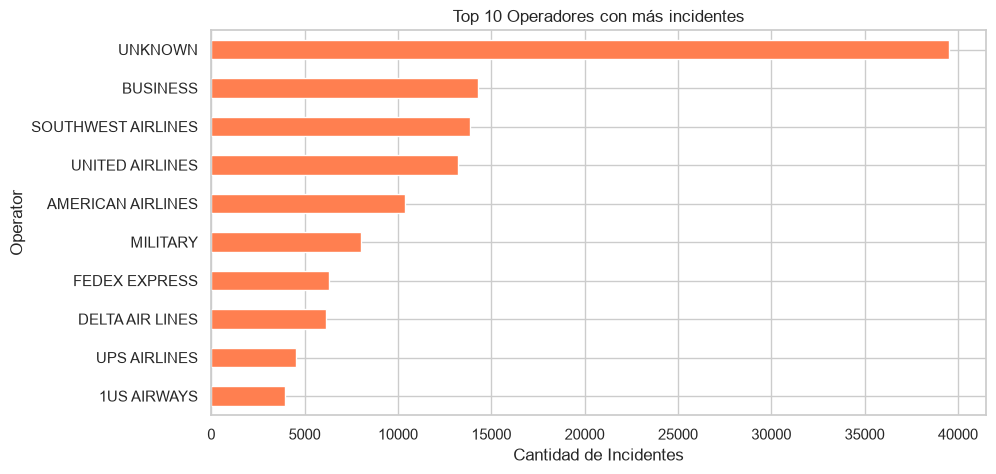

In [20]:
top_operadores = df_analisis['Operator'].value_counts().head(10)
print("Top 10 Operadores:\n", top_operadores)

plt.figure(figsize=(10, 5))
top_operadores.plot(kind='barh', color='coral').invert_yaxis()
plt.title('Top 10 Operadores con más incidentes')
plt.xlabel('Cantidad de Incidentes')
plt.show()

In [21]:
# Definimos cuáles son las columnas numéricas
columnas_numericas = ['Incident Year', 'Incident Month', 'Incident Day']

print("ESTADÍSTICAS NUMÉRICAS\n" + "="*22)

for col in columnas_numericas:
    print(f"--- {col} ---")
    print(f"Media (Promedio): {df[col].mean():.2f}")
    print(f"Mediana (Valor central): {df[col].median()}")
    print(f"Moda (Más frecuente): {df[col].mode()[0]}")
    print(f"Varianza: {df[col].var():.2f}")
    print(f"Desviación Estándar: {df[col].std():.2f}")
    print(f"Rango: Del {df[col].min()} al {df[col].max()}\n")

ESTADÍSTICAS NUMÉRICAS
--- Incident Year ---
Media (Promedio): 2006.04
Mediana (Valor central): 2007.0
Moda (Más frecuente): 2014
Varianza: 45.53
Desviación Estándar: 6.75
Rango: Del 1990 al 2015

--- Incident Month ---
Media (Promedio): 7.17
Mediana (Valor central): 8.0
Moda (Más frecuente): 8
Varianza: 7.78
Desviación Estándar: 2.79
Rango: Del 1 al 12

--- Incident Day ---
Media (Promedio): 15.71
Mediana (Valor central): 16.0
Moda (Más frecuente): 10
Varianza: 77.43
Desviación Estándar: 8.80
Rango: Del 1 al 31



In [22]:
# Definimos las columnas de texto e identificadores
columnas_categoricas = ['Record ID', 'Operator ID', 'Operator', 'Aircraft']

print("ESTADÍSTICAS CATEGÓRICAS\n" + "="*24)

for col in columnas_categoricas:
    print(f"--- {col} ---")
    print(f"Total de registros válidos: {df[col].count()}")
    print(f"Valores únicos distintos: {df[col].nunique()}")
    print(f"Moda (El más frecuente): {df[col].mode()[0]}")
    
    # Para Operador y Aeronave, mostramos el Top 3 para dar más contexto
    if col in ['Operator', 'Aircraft']:
        print(f"Top 3 más comunes:\n{df[col].value_counts().head(3).to_string()}\n")
    else:
        print("") # Salto de línea para los IDs

ESTADÍSTICAS CATEGÓRICAS
--- Record ID ---
Total de registros válidos: 174104
Valores únicos distintos: 174104
Moda (El más frecuente): 1000

--- Operator ID ---
Total de registros válidos: 174104
Valores únicos distintos: 539
Moda (El más frecuente): UNK

--- Operator ---
Total de registros válidos: 174104
Valores únicos distintos: 533
Moda (El más frecuente): UNKNOWN
Top 3 más comunes:
Operator
UNKNOWN               39540
BUSINESS              14271
SOUTHWEST AIRLINES    13864

--- Aircraft ---
Total de registros válidos: 174104
Valores únicos distintos: 656
Moda (El más frecuente): UNKNOWN
Top 3 más comunes:
Aircraft
UNKNOWN      40468
B-737-300     8935
B-737-700     7414



In [5]:
# ==========================================
# PASO 2: Creación de Estaciones del Año y Períodos Históricos
# ==========================================

estaciones_map = {
    12: 'Invierno', 1: 'Invierno', 2: 'Invierno',
    3: 'Primavera', 4: 'Primavera', 5: 'Primavera',
    6: 'Verano', 7: 'Verano', 8: 'Verano',
    9: 'Otoño', 10: 'Otoño', 11: 'Otoño'
}
df['Season'] = df['Incident Month'].map(estaciones_map)

df['Historical_Period'] = pd.cut(
    df['Incident Year'], 
    bins=[1989, 1999, 2008, 2030], 
    labels=['1990-1999', '2000-2008 (Pre-Hudson)', '2009+ (Post-Hudson)']
)

# --- NUEVO CONTROL PASO 2: Agrupado y Acumulado ---
print("\n--- CONTROL PASO 2: Incidentes Acumulados por Estación ---")
# value_counts() cuenta cuántos registros cayeron en cada estación
incidentes_por_estacion = df['Season'].value_counts()
print(incidentes_por_estacion)

print("\n--- Incidentes Acumulados por Período Histórico ---")
# Hacemos lo mismo para el período histórico
incidentes_por_periodo = df['Historical_Period'].value_counts()
print(incidentes_por_periodo)


--- CONTROL PASO 2: Incidentes Acumulados por Estación ---
Season
Verano       61041
Otoño        56187
Primavera    38300
Invierno     18576
Name: count, dtype: int64

--- Incidentes Acumulados por Período Histórico ---
Historical_Period
2009+ (Post-Hudson)       77199
2000-2008 (Pre-Hudson)    64160
1990-1999                 32745
Name: count, dtype: int64


In [7]:
import pandas as pd

# 1. Veamos qué hay dentro de "Otros" antes de cambiar nada
print("--- TOP 15 AERONAVES DENTRO DE 'OTROS' ---")
# Filtramos solo los 'Otros' y contamos los valores originales
otros_top = df[df['Aircraft_Group'] == 'Otros']['Aircraft'].value_counts().head(15)
print(otros_top)

# 2. Función de categorización ampliada (cubre > 80% de la flota comercial y general)
def categorize_aircraft_v2(ac):
    ac = str(ac).upper().strip() # .strip() elimina espacios en blanco accidentales
    
    # 1. No identificados
    if 'UNKNOWN' in ac: 
        return 'Unknown'
    
    # 2. Aviación Ejecutiva / Negocios
    elif 'BUSINESS' in ac or 'CORPORATE' in ac: 
        return 'Business / Ejecutiva'
    
    # 3. Jets Regionales (Suelen tener muchos incidentes por volar bajo y corto)
    elif any(x in ac for x in ['EMB', 'ERJ', 'CRJ', 'CL-600']):
        return 'Regional Jet'
    
    # 4. Comerciales de Fuselaje Estrecho (Un pasillo)
    elif any(x in ac for x in ['B-737', 'B737', 'A-320', 'A320', 'A-319', 'A-321', 'B-757', 'B-717', 'MD-8']): 
        return 'Commercial Narrow-body'
        
    # 5. Comerciales de Fuselaje Ancho (Doble pasillo)
    elif any(x in ac for x in ['B-767', 'B-777', 'B-787', 'B-747', 'A-330', 'A-340', 'A-350', 'A-380']):
        return 'Commercial Wide-body'
        
    # 6. Aviación General Ligera (Cessna, Piper, Beechcraft)
    elif any(x in ac for x in ['C-172', 'C-152', 'PA-', 'BE-']):
        return 'General Aviation (Light)'
        
    # 7. El resto
    else:
        return 'Otros'

# Aplicamos la nueva función
df['Aircraft_Group'] = df['Aircraft'].apply(categorize_aircraft_v2)

print("\n--- CONTROL PASO 3 ACTUALIZADO: Grupos de Aeronaves ---")
print(df['Aircraft_Group'].value_counts())

--- TOP 15 AERONAVES DENTRO DE 'OTROS' ---
Aircraft
CRJ100/200     6369
B-757-200      6327
A-319          4501
EMB-145        3584
B-727-200      3136
A-300          2953
DHC8 DASH 8    2404
MD-80          2400
B-767-300      2241
MD-82          2236
CRJ700         2076
C-172          1700
SAAB-340       1605
EMB-170        1509
MD-11          1449
Name: count, dtype: int64

--- CONTROL PASO 3 ACTUALIZADO: Grupos de Aeronaves ---
Aircraft_Group
Commercial Narrow-body      55704
Otros                       44904
Unknown                     40469
Regional Jet                18432
General Aviation (Light)     8347
Commercial Wide-body         6248
Name: count, dtype: int64


In [9]:
# ==========================================
# PASO 4: CRUCES Y TABULACIONES CRUZADAS
# ==========================================

# 1. Cruce: Estación del Año vs. Grupo de Aeronave
# Usamos margins=True para que nos agregue la fila y columna de "Total" (All)
cruce_estacion_aeronave = pd.crosstab(
    df['Season'], 
    df['Aircraft_Group'], 
    margins=True, 
    margins_name="Total"
)

# 2. Cruce: Evolución Histórica de la Calidad del Reporte
# Calculamos el % de registros que tienen a su Operador como "UNKNOWN" agrupado por Año
df['Is_Unknown_Operator'] = df['Operator'] == 'UNKNOWN'
calidad_reporte_anio = df.groupby('Incident Year')['Is_Unknown_Operator'].mean() * 100

# --- CONTROL PASO 4: Salida por Consola ---
print("\n" + "="*60)
print("--- CRUCE 1: ESTACIÓN VS GRUPO DE AERONAVE ---")
print("="*60)
# Mostramos la tabla. Ordenamos por el Total de mayor a menor para leerla mejor
print(cruce_estacion_aeronave.sort_values(by='Total', ascending=False))

print("\n" + "="*60)
print("--- CRUCE 2: % DE OPERADORES 'UNKNOWN' POR AÑO (Últimos 10 años) ---")
print("="*60)
# Mostramos cómo fue mejorando/empeorando el reporte en la última década
print(calidad_reporte_anio.tail(10).round(2).astype(str) + ' %')


--- CRUCE 1: ESTACIÓN VS GRUPO DE AERONAVE ---
Aircraft_Group  Commercial Narrow-body  Commercial Wide-body  \
Season                                                         
Total                            55704                  6248   
Verano                           17432                  1774   
Otoño                            18803                  2138   
Primavera                        13351                  1588   
Invierno                          6118                   748   

Aircraft_Group  General Aviation (Light)  Otros  Regional Jet  Unknown   Total  
Season                                                                          
Total                               8347  44904         18432    40469  174104  
Verano                              2774  14258          7169    17634   61041  
Otoño                               2762  15420          5923    11141   56187  
Primavera                           1721  10567          3635     7438   38300  
Invierno         